In [1]:
using Random, Statistics, Plots, ProgressMeter, JSON

ArgumentError: ArgumentError: Package JSON not found in current path.
- Run `import Pkg; Pkg.add("JSON")` to install the JSON package.

In [2]:
# Helper function to sample an integer from a power law distribution.
function sample_powerlaw_int(min_length::Int, max_length::Int, alpha::Float64)
    # Generate a uniform random number between 0 and 1.
    u = rand()
    # Inverse transform sampling for a power law:
    #   F(x) = (x^(1-α) - min_length^(1-α)) / (max_length^(1-α) - min_length^(1-α))
    # Solving for x gives:
    x = ((u * (max_length^(1 - alpha) - min_length^(1 - alpha))) + min_length^(1 - alpha))^(1 / (1 - alpha))
    # Ensure the returned length is at least min_length and at most max_length.
    slice_length = max(min_length, min(max_length, round(Int, x)))
    return slice_length
end

sample_powerlaw_int (generic function with 1 method)

# Chromosomes

In [4]:
# Chromosomes Type and Functions
# -------------------------------
mutable struct Chromosomes
    chromosomes_gene_type::Vector{Vector{Int}}
    chromosomes_gene_mut::Vector{Vector{Int}}
    gene_map::Dict{Int,String}
end

function get_Nchrs(ch::Chromosomes)
    if length(ch.chromosomes_gene_type) == length(ch.chromosomes_gene_mut)
        return length(ch.chromosomes_gene_type)
    else
        error("Mismatched chromosome lists.")
    end
end

function get_Ngenes(ch::Chromosomes)
    ngenes = 0
    if length(ch.chromosomes_gene_type) == length(ch.chromosomes_gene_mut)
        for i in 1:length(ch.chromosomes_gene_type)
            if length(ch.chromosomes_gene_type[i]) == length(ch.chromosomes_gene_mut[i])
                ngenes = ngenes+length(ch.chromosomes_gene_type[i])
            else
                error("Mismatched genes lenghts")
            end
        end
        return ngenes
    else
        error("Mismatched chromosome lists.")
    end
end

function mutate!(ch::Chromosomes, mu::Float64)
    n_mut = 0
    for i in 1:get_Nchrs(ch)
        chrom = ch.chromosomes_gene_mut[i]
        # For each gene in the chromosome, mutate with probability mu.
        for j in 1:length(chrom)
            if rand() < mu
                chrom[j] = 1
            end
        end
        ch.chromosomes_gene_mut[i] = chrom
    end
end

function crossover!(ch::Chromosomes, ext_chr_gt::Vector{Int}, ext_chr_gm::Vector{Int})
    idx_chr = rand(1:get_Nchrs(ch))
    ch.chromosomes_gene_type[idx_chr] = vcat(ch.chromosomes_gene_type[idx_chr], ext_chr_gt)
    ch.chromosomes_gene_mut[idx_chr]  = vcat(ch.chromosomes_gene_mut[idx_chr], ext_chr_gm)
end

function get_genes_by_type(ch::Chromosomes, gene_type::String)
    restr_gene_mut_gt = Vector{Vector{Int}}()
    restr_gene_mut_gm = Vector{Vector{Int}}()
    for i in 1:length(ch.chromosomes_gene_type)
        mapped = [ch.gene_map[x] for x in ch.chromosomes_gene_type[i]]
        inds = findall(x -> x == gene_type, mapped)
        push!(restr_gene_mut_gt, ch.chromosomes_gene_type[i][inds])
        push!(restr_gene_mut_gm, ch.chromosomes_gene_mut[i][inds])
    end
    return restr_gene_mut_gt, restr_gene_mut_gm
end


get_genes_by_type (generic function with 1 method)

# Cell

In [5]:
# Cell Type and Methods
# ---------------------
mutable struct Cell
    x::Int
    y::Int
    chromosomes::Chromosomes
    mu0::Float64
    dmu::Float64
    mumax::Float64
    mu::Float64
    r0::Float64
    dr::Float64
    rmax::Float64
    r::Float64
end

get_Nchrs(cell::Cell) = get_Nchrs(cell.chromosomes)

"""
    compute_activation(cell, gene_type; mode="any")

Helper function that computes, for a given gene type, an activation Boolean vector
across the unique genes. For mode "any", a gene is activated if at least one chromosome
has it mutated; for mode "all", only if all chromosomes show the mutation.
"""
function compute_activation(cell::Cell, gene_type::String; mode::String="any")
    gene_types, gene_muts = get_genes_by_type(cell.chromosomes, gene_type)
    if all(x -> isempty(x), gene_types)
        return Bool[]
    end
    unique_genes = unique(vcat(gene_types...))
    # For each chromosome, build a Boolean vector indicating for each unique gene if any matching gene is mutated.
    if mode == "any"
        # A gene is activated if any chromosome shows it.
        activation = [ [ any(gene_muts[i][findall(x -> x == ug, gene_types[i])] .== 1) for ug in unique_genes ]
                   for i in 1:length(gene_types) ]
        return [ any(activation[i][j] for i in 1:length(activation)) for j in 1:length(unique_genes) ]
    elseif mode == "all"
        # A gene is activated only if every chromosome shows it.
        activation = [ [ all(gene_muts[i][findall(x -> x == ug, gene_types[i])] .== 1) for ug in unique_genes ]
                   for i in 1:length(gene_types) ]
        return [ all(activation[i][j] for i in 1:length(activation)) for j in 1:length(unique_genes) ]
    else
        error("Invalid mode. Use \"any\" or \"all\".")
    end
end

function update_mu!(cell::Cell)
    act = compute_activation(cell, "I"; mode="any")
    new_mu = cell.mu0 + sum(act) * cell.dmu
    cell.mu = new_mu < cell.mumax ? new_mu : cell.mumax
end

function update_r!(cell::Cell)
    act_o = compute_activation(cell, "O"; mode="any")
    act_s = compute_activation(cell, "S"; mode="all")
    new_r = cell.r0 + (sum(act_o) + sum(act_s)) * cell.dr
    cell.r = new_r < cell.rmax ? new_r : cell.rmax
end

reproduce(cell::Cell) = rand() < cell.r

function check_cell_death(cell::Cell)
    if get_Nchrs(cell) == 0
        return true
    end
    act_hk = compute_activation(cell, "HK"; mode="all")
    return any(act_hk)
end

"""
    update!(cell)

Updates the cell state: first checks for cell death, then applies mutation, and updates
the mutation and reproduction rates. Returns 0 if the cell dies, 1 if it reproduces,
or 2 if nothing happens.
"""
function update!(cell::Cell)
    if check_cell_death(cell)
        return 0  # Death
    end
    mutate!(cell.chromosomes, cell.mu)
    update_mu!(cell)
    update_r!(cell)
    return reproduce(cell) ? 1 : 2
end

function copy_cell(cell::Cell)
    new_chromosomes = Chromosomes([copy(arr) for arr in cell.chromosomes.chromosomes_gene_type],
                                  [copy(arr) for arr in cell.chromosomes.chromosomes_gene_mut],
                                  deepcopy(cell.chromosomes.gene_map))
    return Cell(cell.x, cell.y, new_chromosomes, cell.mu0, cell.dmu, cell.mumax,
                cell.mu, cell.r0, cell.dr, cell.rmax, cell.r)
end

"""
    replicate_split_chromosomes(cell)

Replicates a cell while splitting one randomly selected chromosome.
The mother loses the selected chromosome and the daughter gains an extra copy.
"""
function replicate_split_chromosomes(cell::Cell)
    n_chrs = get_Nchrs(cell)
    idx_chr = rand(1:n_chrs)
    mother = copy_cell(cell)
    daughter = copy_cell(cell)
    # Remove the selected chromosome from the mother.
    splice!(mother.chromosomes.chromosomes_gene_type, idx_chr)
    splice!(mother.chromosomes.chromosomes_gene_mut, idx_chr)
    # Append a copy of the selected chromosome to the daughter.
    push!(daughter.chromosomes.chromosomes_gene_type, copy(daughter.chromosomes.chromosomes_gene_type[idx_chr]))
    push!(daughter.chromosomes.chromosomes_gene_mut, copy(daughter.chromosomes.chromosomes_gene_mut[idx_chr]))
    return mother, daughter
end


function replicate_cell_slice(cell::Cell)
    n_chrs = get_Nchrs(cell)
    # Choose a random chromosome index.
    idx_chr = rand(1:n_chrs)
    
    # Create deep copies for both mother and daughter.
    mother = copy_cell(cell)
    daughter = copy_cell(cell)
    
    # Get the chosen chromosome arrays (gene types and mutations) for the selected chromosome.
    mother_gene_type = mother.chromosomes.chromosomes_gene_type[idx_chr]
    mother_gene_mut = mother.chromosomes.chromosomes_gene_mut[idx_chr]
    L_chr = length(mother_gene_type)
    
    # Choose a random contiguous slice.
    if L_chr > 1
        start_idx = rand(1:L_chr)
        # Maximum possible slice length is determined by remaining elements.
        max_length = L_chr - start_idx + 1
        # Sample the slice length from a power law distribution.
        slice_length = sample_powerlaw_int(1, max_length, 2.)
        end_idx = start_idx + slice_length - 1
    else
        start_idx = 1
        end_idx = 1
    end
    
    # Extract the slice.
    slice_gene_type = mother_gene_type[start_idx:end_idx]
    slice_gene_mut = mother_gene_mut[start_idx:end_idx]
    
    # Remove the slice from the mother's chromosome.
    deleteat!(mother_gene_type, start_idx:end_idx)
    deleteat!(mother_gene_mut, start_idx:end_idx)
    mother.chromosomes.chromosomes_gene_type[idx_chr] = mother_gene_type
    mother.chromosomes.chromosomes_gene_mut[idx_chr] = mother_gene_mut
    
    # Add the slice as a new chromosome to the daughter.
    daughter.chromosomes.chromosomes_gene_type[idx_chr] = vcat(
        daughter.chromosomes.chromosomes_gene_type[idx_chr],
        copy(slice_gene_type)
    )
    daughter.chromosomes.chromosomes_gene_mut[idx_chr] = vcat(
        daughter.chromosomes.chromosomes_gene_mut[idx_chr],
        copy(slice_gene_mut)
    )
    
    return mother, daughter
end

replicate_cell_slice (generic function with 1 method)

# Tissue

In [6]:
# Tissue Type and Functions
# -------------------------
mutable struct Tissue
    L::Int
    cells::Array{Cell,2}
    p_poly::Float64
    p_cross::Float64
    gene_map::Dict{Int,String}
    neighbor_cache::Dict{Tuple{Int,Int}, Vector{Tuple{Int,Int}}}
end

function compute_neighbors(L::Int, row::Int, col::Int)
    neighbors = Vector{Tuple{Int,Int}}()
    for dr in -1:1
        for dc in -1:1
            if dr == 0 && dc == 0
                continue
            end
            new_row = row + dr
            new_col = col + dc
            if new_row ≥ 1 && new_row ≤ L && new_col ≥ 1 && new_col ≤ L
                push!(neighbors, (new_row, new_col))
            end
        end
    end
    return neighbors
end

function Tissue(L::Int, init_cell_state::Array{Cell,2}, p_poly::Float64, p_cross::Float64)
    gene_map = init_cell_state[1,1].chromosomes.gene_map
    neighbor_cache = Dict{Tuple{Int,Int}, Vector{Tuple{Int,Int}}}()
    for i in 1:L, j in 1:L
        neighbor_cache[(i,j)] = compute_neighbors(L, i, j)
    end
    return Tissue(L, init_cell_state, p_poly, p_cross, gene_map, neighbor_cache)
end

get_neighbors(tiss::Tissue, row::Int, col::Int) = tiss.neighbor_cache[(row, col)]

function get_actions(tiss::Tissue)
    actions = zeros(Int, tiss.L, tiss.L)
    for i in 1:tiss.L, j in 1:tiss.L
        actions[i, j] = update!(tiss.cells[i,j])
    end
    return actions
end

# Helper function for weighted random selection.
function weighted_choice(neighbors::Vector{Tuple{Int,Int}}, weights::Vector{Float64})
    total = sum(weights)
    r = rand() * total
    cum = 0.0
    for (i, w) in enumerate(weights)
        cum += w
        if r < cum
            return neighbors[i]
        end
    end
    return neighbors[end]
end

"""
    substitute!(tiss, action)

For cells that died (action 0), replace them with a copy of a neighbor chosen
with probability proportional to its reproduction rate.
For cells that reproduced (action 1), a neighbor is replaced by a copy of the cell,
or by a split replication with probability p_poly, choosing a neighbot with probability
inversely proportional to the reproduction rate
"""
function substitute!(tiss::Tissue, action::Array{Int,2})
    L = tiss.L
    # Process death cells.
    for i in 1:L, j in 1:L
        if action[i, j] == 0
            neighs = get_neighbors(tiss, i, j)
            rates = [tiss.cells[r, c].r for (r, c) in neighs]
            chosen = weighted_choice(neighs, rates)
            tiss.cells[i, j] = copy_cell(tiss.cells[chosen[1], chosen[2]])
        end
    end
    # Process reproducing cells.
    for i in 1:L, j in 1:L
        if action[i, j] == 1
            neighs = get_neighbors(tiss, i, j)
            rates = [tiss.cells[r, c].r for (r, c) in neighs]
            inv_rates = 1.0 ./ rates
            chosen = weighted_choice(neighs, inv_rates)
            if rand() < tiss.p_poly
                mother, daughter = replicate_split_chromosomes(tiss.cells[i,j])
                tiss.cells[i, j] = mother
                tiss.cells[chosen[1], chosen[2]] = daughter
            elseif rand() < tiss.p_cross
                mother, daughter = replicate_cell_slice(tiss.cells[i,j])
                tiss.cells[i, j] = mother
                tiss.cells[chosen[1], chosen[2]] = daughter
            else
                tiss.cells[chosen[1], chosen[2]] = copy_cell(tiss.cells[i,j])
            end
        end
    end
end

function update!(tiss::Tissue)
    action = get_actions(tiss)
    substitute!(tiss, action)
    return action
end

function get_r(tiss::Tissue)
    r_mat = zeros(Float64, tiss.L, tiss.L)
    for i in 1:tiss.L, j in 1:tiss.L
        r_mat[i, j] = tiss.cells[i,j].r
    end
    return r_mat
end

function get_mu(tiss::Tissue)
    mu_mat = zeros(Float64, tiss.L, tiss.L)
    for i in 1:tiss.L, j in 1:tiss.L
        mu_mat[i, j] = tiss.cells[i,j].mu
    end
    return mu_mat
end

function get_Nchrs(tiss::Tissue)
    n_mat = zeros(Int, tiss.L, tiss.L)
    for i in 1:tiss.L, j in 1:tiss.L
        n_mat[i, j] = get_Nchrs(tiss.cells[i,j])
    end
    return n_mat
end

function get_avg_genemutation(tiss::Tissue, gene_types::Vector{String})
    # Determine keys (indices) of genes matching the provided gene_types.
    selected_keys = Int[]
    for gt in gene_types
        for (k, v) in tiss.gene_map
            if v == gt
                push!(selected_keys, k)
            end
        end
    end
    selected_keys = unique(selected_keys)
    
    # Create an output matrix filled with NaN.
    mut_state = fill(NaN, tiss.L, tiss.L)
    
    for i in 1:tiss.L, j in 1:tiss.L
        cell = tiss.cells[i,j]
        if get_Nchrs(cell) == 0
            mut_state[i,j] = NaN
        else
            means = Float64[]
            for c in 1:length(cell.chromosomes.chromosomes_gene_mut)
                # Get the gene types and mutation values for chromosome c.
                gene_types_vec = cell.chromosomes.chromosomes_gene_type[c]
                gene_mut_vec = cell.chromosomes.chromosomes_gene_mut[c]
                # Find indices where the gene type is one of the selected keys.
                idxs = findall(x -> x in selected_keys, gene_types_vec)
                if !isempty(idxs)
                    push!(means, mean(gene_mut_vec[idxs]))
                end
            end
            mut_state[i,j] = mean(means)
        end
    end
    return mut_state
end

function get_Ngenes(tiss::Tissue)
    n_mat = zeros(Int, tiss.L, tiss.L)
    for i in 1:tiss.L, j in 1:tiss.L
        n_mat[i, j] = get_Ngenes(tiss.cells[i,j].chromosomes)
    end
    return n_mat
end

get_Ngenes (generic function with 2 methods)

In [7]:
# Tissue Initialization
# --------------------
function init_tissue(L::Int, chrom_gene_type::Vector{Vector{Int}}, chrom_gene_mut::Vector{Vector{Int}}, 
    gene_map::Dict{Int,String}, mu0::Float64, dmu::Float64, mumax::Float64, 
    r0::Float64, dr::Float64, rmax::Float64)
cells = Array{Cell}(undef, L, L)
for i in 1:L, j in 1:L
ch = Chromosomes(copy(chrom_gene_type), copy(chrom_gene_mut), gene_map)
cells[i,j] = Cell(i, j, ch, mu0, dmu, mumax, mu0, r0, dr, rmax, r0)
end
return cells
end

init_tissue (generic function with 1 method)

# Simulation

In [8]:
# Track genomic space transitions
# -------------------------------

# Helper function: converts a cell's genomic state into a canonical string.
# Here we use the mutation arrays for each chromosome.
function get_genomic_state(cell::Cell, gene_map::Dict{Int,String})
    cell = copy_cell(cell)
    chrom_gene_type = cell.chromosomes.chromosomes_gene_type
    chrom_gene_mut = cell.chromosomes.chromosomes_gene_mut
    n_ch = length(gene_map)  # number of distinct gene entries
    counts_ch = Vector[]
    mutation_ch = Vector[]
    
    for i in 1:length(chrom_gene_mut)
        counts = zeros(Int, n_ch)
        mutation_sums = zeros(Int, n_ch)
        for (gt, m) in zip(chrom_gene_type[i], chrom_gene_mut[i])
            counts[gt] += 1
            mutation_sums[gt] += m
        end
        push!(counts_ch, counts)
        push!(mutation_ch, mutation_sums)
    end

    # For gene types, join each chromosome with "-" then join the chromosomes with "/"
    types_str = join((join(count,"") for count in counts_ch),"/")
    # For gene mutations, do the same
    muts_str  = join((join(mutation,"") for mutation in mutation_ch),"/")
    # Combine both parts with a "+"
    return "$types_str+$muts_str"
end

# Function to record a transition from prev_state to new_state.
function track_transition!(prev_state::String, new_state::String)
    key = (prev_state, new_state)
    # Increment the count if the key exists, otherwise initialize it to 1.
    STATE_SPACE[key] = get(STATE_SPACE, key, 0) + 1
end

function save_genomicstate(state_space::Dict{Tuple{String, String}, Int}, fname::String, dname::String)
    # 1. Collect all unique states from the keys.
    all_states = unique(vcat([k[1] for k in keys(state_space)],
                             [k[2] for k in keys(state_space)]))
    
    # 2. Create a dictionary mapping each state string to a unique number.
    state_dict = Dict(state => i for (i, state) in enumerate(all_states))
    
    # 3. Create a vector of triples: (state_out_number, state_in_number, transition count).
    transitions = [(state_dict[k[1]], state_dict[k[2]], count) for (k, count) in state_space]
    
    # For example, print the state mapping and the transitions vector:
    
    
    open(fname, "w") do io
        for (state_out, state_in, count) in transitions
            println(io, "$state_out $state_in $count")
        end
    end

    json_str = JSON.json(state_dict)
    open(dname, "w") do io
        write(io, json_str)
    end
    return state_dict
end

save_genomicstate (generic function with 1 method)

In [9]:
# Create Gene Map 
# ---------------

function create_gene_map(n_I::Int, n_O::Int, n_S::Int, n_HK::Int)
    types = vcat(fill("I", n_I), fill("O", n_O), fill("S", n_S), fill("HK", n_HK))
    return Dict(i => types[i] for i in 1:length(types))
end

create_gene_map (generic function with 1 method)

In [10]:
# Model and Simulation
# --------------------
# Model parameters
gene_map = create_gene_map(6, 4, 4, 2)
N0_genes = length(gene_map)

chrom_gene_type = [collect(1:N0_genes), collect(1:N0_genes)]
chrom_gene_mut  = [zeros(Int, N0_genes), zeros(Int, N0_genes)]
L = 50
mu0   = 1e-8
dmu   = 5e-4
mumax = 1e-1
r0    = 1e-2
dr    = 8e-4
rmax  = 2 * r0
p_poly = 5e-4
p_cross = 1e-3

# Global dictionary to track transitions between genomic states.
# The keys are tuples: (previous_state, new_state), and the value is the count.
STATE_SPACE = Dict{Tuple{String, String}, Int}()

print("Parameters initialized")

Parameters initialized

In [11]:
# Initialization
# --------------

init_state = init_tissue(L, chrom_gene_type, chrom_gene_mut, gene_map, mu0, dmu, mumax, r0, dr, rmax)

# Introduce a perturbation in the central cell.
# For the perturbation, we add a third chromosome with a mutation.
pert_chrom_gene_type = [collect(1:N0_genes), collect(1:N0_genes)]
pert_chrom_gene_mut  = [zeros(Int, N0_genes), zeros(Int, N0_genes)]
# In Julia, index 2 corresponds to the second gene (since indexing starts at 1).
pert_chrom_gene_mut[2][2] = 1
pert_chrom_gene_mut[1][6] = 1
ch_pert = Chromosomes(pert_chrom_gene_type, pert_chrom_gene_mut, gene_map)
center = div(L, 2)
init_state[center, center] = Cell(center, center, ch_pert, mu0, dmu, mumax, mu0, r0, dr, rmax, r0)

# Create the tissue.
tiss = Tissue(L, init_state, p_poly, p_cross)
##
mus = Float64[]
rs = Float64[]
ngs = Float64[]
tissues = Tissue[]

print("System initialized")

System initialized

In [12]:
# Simulation loop
@showprogress for k in 1:2000
    # Update system and track transition in genomic space
    old_state = String[]
    for i in 1:L, j in 1:L
        push!(old_state, get_genomic_state(tiss.cells[i,j], tiss.gene_map))
    end
    update!(tiss)  # Update system state
    new_state = String[]
    for i in 1:L, j in 1:L
        push!(new_state, get_genomic_state(tiss.cells[i,j], tiss.gene_map))
    end
    for i in 1:L*L
        track_transition!(old_state[i], new_state[i])
    end
    # Save important quantities
    mu = get_mu(tiss)
    r = mean(get_r(tiss))
    ng = mean(get_Ngenes(tiss))
    push!(mus, mean(mu))
    push!(rs, r)
    push!(ngs, ng)
    if rem(100, k)==0
        push!(tissues, tiss)
    end
    if all(mu.==mu0)
        println("All normal cells at iteration ", k)
        break
    end
end

pmu = plot(mus, title="mu")
pr = plot(ngs, title="N genes")
p_progr = plot(pmu, pr, layout = (1, 2), size = (1000, 400))
savefig(p_progr, "images/progr_example.png")

Progress:   9%|███▋                                     |  ETA: 0:03:02

All normal cells at iteration 178

Progress: 100%|█████████████████████████████████████████| Time: 0:00:17


"/home/francesco/Desktop/PhD/PROJECTS/CancerEvo/images/progr_example.png"

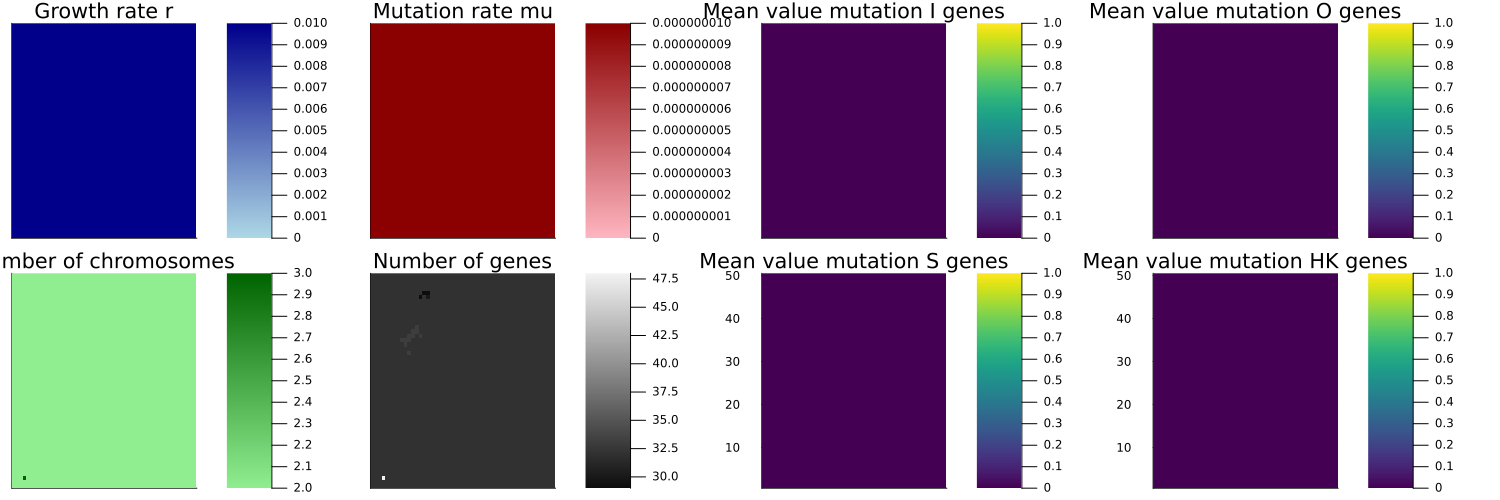

In [14]:
# Create the individual heatmap plots:
p1 = heatmap(get_r(tiss),
             color = :blues,
             #clims = (r0, rmax),
             title = "Growth rate r",
             xticks = false,
             yticks = false)

p2 = heatmap(get_mu(tiss),
             color = :reds,
             #clims = (0, 5), # adjust as needed
             title = "Mutation rate mu",
             xticks = false,
             yticks = false)

p3 = heatmap(get_Nchrs(tiss),
             color = :greens,
             #clims = (r0, rmax),
             title = "Number of chromosomes",
             xticks = false,
             yticks = false)

p4 = heatmap(get_Ngenes(tiss),
             color = :grays,
             #clims = (0, 5), # adjust as needed
             title = "Number of genes",
             xticks = false,
             yticks = false)

gtype_p5 = ["I"]
p5 = heatmap(get_avg_genemutation(tiss, gtype_p5),
             color = :viridis,
             clims = (0, 1),
             title = "Mean value mutation " * join(gtype_p5, "-") * " genes",
             xticks = false,
             yticks = false)
gtype_p6 = ["O"]
p6 = heatmap(get_avg_genemutation(tiss, gtype_p6),
             color = :viridis,
             clims = (0, 1),
             title = "Mean value mutation " * join(gtype_p6, "-") * " genes",
             xticks = false,
             yticks = false)
gtype_p7 = ["S"]
p7 = heatmap(get_avg_genemutation(tiss, gtype_p7),
             color = :viridis,
             clims = (0, 1),
             title = "Mean value mutation " * join(gtype_p7, "-") * " genes",
             xticks = false)
gtype_p8 = ["HK"]
p8 = heatmap(get_avg_genemutation(tiss, gtype_p8),
             color = :viridis,
             clims = (0, 1),
             title = "Mean value mutation " * join(gtype_p8, "-") * " genes",
             xticks = false)
# Combine the subplots in a 2x2 grid.
p_res = plot(p1, p2, p5, p6, p3, p4, p7, p8, layout = (2, 4), size = (1500, 500))
#savefig(p_res, "images/finaldistr_example.png")

In [51]:
state_dict = save_genomicstate(STATE_SPACE, "transitions.txt", "state_map.txt")

Dict{String, Int64} with 314 entries:
  "1111111111111111/1111111111111111+1011111111111100/1111001110011011" => 87
  "1111111111100001/1111111111111111+0000000000000000/0000000000000000" => 30
  "1111111111111111/1111111111111111+0000010100010010/0101000100000001" => 63
  "1111111111101111/1111111111111111+1111111111101110/1111111111111111" => 277
  "1111111111111111/1111111111111111+1011110111101100/1111001110011011" => 71
  "1111122221111111/1111111111111111+0000000000000000/0000000000000000" => 282
  "1111111111111111/1111111111111111+1001111111111101/1111110110011010" => 204
  "1111111111111111/1111111111111111+1111111111111110/1111111110111111" => 73
  "1111111111110111/1111111111111111+0000000000000000/0000000000000000" => 284
  "1111111111111111/1111111111111111+1111111111111100/1111111011011111" => 7
  "1111111111111111/1111111111111111+0110010100100000/0101001100000000" => 254
  "1111111111111111/1111111111111111+0100010010000000/0100101000000000" => 180
  "1111111111111111/1

In [32]:
STATE_SPACE

Dict{Tuple{String, String}, Int64} with 3 entries:
  ("1111111111111111/1111111111111111+0000010000000000/010000000000000… => 22
  ("1111111111111111/1111111111111111+0000010000000000/010000000000000… => 1
  ("1111111111111111/1111111111111111+0000000000000000/000000000000000… => 57477